#Telecom Churn Prediction Project
#Part 1 — Project Introduction, Import Libraries, Load Dataset & Data Overview
#Step 1: Project Title

# Telecom Customer Churn Prediction

## Business Problem

Customer churn is one of the biggest challenges faced by telecommunication companies. Losing customers directly affects revenue and increases customer acquisition costs. Studies have shown that acquiring a new customer is significantly more expensive than retaining an existing one.

This project aims to develop a machine learning model capable of predicting customer churn based on customer demographics, subscribed services, and account information.

The project also aims to identify the major factors contributing to churn and provide business recommendations for improving customer retention.

#Step 2: Objectives
## Project Objectives

The objectives of this project are:

- Predict whether a customer will churn.
- Identify the important factors affecting customer churn.
- Compare multiple machine learning algorithms.
- Select the best-performing model.
- Explain model predictions using SHAP Explainability.
- Provide actionable business recommendations to reduce churn.

In [3]:
#Step 3: Import Libraries
# ==========================================================
# Import Required Libraries
# ==========================================================

# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Display all columns
pd.set_option('display.max_columns', None)

# Display wider tables
pd.set_option('display.width', 1000)

# Set visualization style
sns.set(style="whitegrid")

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


In [7]:
#Step 4: Load Dataset
# ==========================================================

# Import pandas (if not already imported)
import pandas as pd

# Read the CSV file from the specified file path
df = pd.read_csv(
    r"C:\Users\sagni\Downloads\Telco Churn Prediction Data\WA_Fn-UseC_-Telco-Customer-Churn.csv"
)

# Display the first five rows of the dataset
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


#Step 5: Dataset Shape
## Dataset Dimensions

Understanding the number of observations (rows) and variables (columns) helps estimate the size and complexity of the dataset.

In [10]:
# Shape of dataset

print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 7043
Columns : 21


In [12]:
#Step 6: Display Sample Data
# Display first 10 records

df.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,Yes,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


#Step 7: Check Column Names
## Column Names

Reviewing the column names helps us understand the available features and identify any inconsistencies in naming conventions.

In [15]:
# Display column names

df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'], dtype='object')

#Step 8: Convert Column Names to snake_case
## Convert Column Names to Snake Case

To improve code readability and follow Python naming conventions, all column names are converted from CamelCase to snake_case.

In [18]:
# ==========================================================
# Convert Column Names to Snake Case
# ==========================================================

# Rename columns
df.columns = [
    'customer_id',
    'gender',
    'senior_citizen',
    'partner',
    'dependents',
    'tenure',
    'phone_service',
    'multiple_lines',
    'internet_service',
    'online_security',
    'online_backup',
    'device_protection',
    'tech_support',
    'streaming_tv',
    'streaming_movies',
    'contract',
    'paperless_billing',
    'payment_method',
    'monthly_charges',
    'total_charges',
    'churn'
]

# Display updated columns
df.columns

Index(['customer_id', 'gender', 'senior_citizen', 'partner', 'dependents', 'tenure', 'phone_service', 'multiple_lines', 'internet_service', 'online_security', 'online_backup', 'device_protection', 'tech_support', 'streaming_tv', 'streaming_movies', 'contract', 'paperless_billing', 'payment_method', 'monthly_charges', 'total_charges', 'churn'], dtype='object')

#Step 9: Data Types
## Data Types

Understanding the data type of each variable is important because machine learning algorithms require numerical inputs, and incorrect data types can affect preprocessing and model performance.

In [21]:
# Display data types

df.dtypes

customer_id           object
gender                object
senior_citizen         int64
partner               object
dependents            object
tenure                 int64
phone_service         object
multiple_lines        object
internet_service      object
online_security       object
online_backup         object
device_protection     object
tech_support          object
streaming_tv          object
streaming_movies      object
contract              object
paperless_billing     object
payment_method        object
monthly_charges      float64
total_charges         object
churn                 object
dtype: object

In [23]:
#Step 10: Dataset Information
# Dataset summary

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customer_id        7043 non-null   object 
 1   gender             7043 non-null   object 
 2   senior_citizen     7043 non-null   int64  
 3   partner            7043 non-null   object 
 4   dependents         7043 non-null   object 
 5   tenure             7043 non-null   int64  
 6   phone_service      7043 non-null   object 
 7   multiple_lines     7043 non-null   object 
 8   internet_service   7043 non-null   object 
 9   online_security    7043 non-null   object 
 10  online_backup      7043 non-null   object 
 11  device_protection  7043 non-null   object 
 12  tech_support       7043 non-null   object 
 13  streaming_tv       7043 non-null   object 
 14  streaming_movies   7043 non-null   object 
 15  contract           7043 non-null   object 
 16  paperless_billing  7043 

#Step 11: Statistical Summary
## Descriptive Statistics

Summary statistics provide insights into the distribution, central tendency, and variability of numerical variables in the dataset.

In [26]:
# Statistical summary

df.describe().T

,count,mean,std,min,25%,50%,75%,max
senior_citizen,7043.0,0.162147,0.368612,0.00,0.0,0.00,0.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.0,29.00,55.00,72.00
monthly_charges,7043.0,64.761692,30.090047,18.25,35.5,70.35,89.85,118.75


In [28]:
#Step 12: Statistical Summary for Categorical Variables
# Summary of categorical variables

df.describe(include='object').T

,count,unique,top,freq
customer_id,7043,7043,7590-VHVEG,1
gender,7043,2,Male,3555
partner,7043,2,No,3641
dependents,7043,2,No,4933
phone_service,7043,2,Yes,6361
multiple_lines,7043,3,No,3390
internet_service,7043,3,Fiber optic,3096
online_security,7043,3,No,3498
online_backup,7043,3,No,3088
device_protection,7043,3,No,3095


#Step 13: Check Missing Values
## Missing Value Analysis

Missing values can affect model performance and must be identified before further analysis.

In [31]:
# Missing values

df.isnull().sum()

customer_id          0
gender               0
senior_citizen       0
partner              0
dependents           0
tenure               0
phone_service        0
multiple_lines       0
internet_service     0
online_security      0
online_backup        0
device_protection    0
tech_support         0
streaming_tv         0
streaming_movies     0
contract             0
paperless_billing    0
payment_method       0
monthly_charges      0
total_charges        0
churn                0
dtype: int64

In [33]:
#Step 14: Missing Value Percentage
# Percentage of missing values

missing = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Percentage': round(df.isnull().mean()*100,2)
})

missing

,Missing Values,Percentage
customer_id,0,0.0
gender,0,0.0
senior_citizen,0,0.0
partner,0,0.0
dependents,0,0.0
tenure,0,0.0
phone_service,0,0.0
multiple_lines,0,0.0
internet_service,0,0.0
online_security,0,0.0


#Step 15: Duplicate Records
## Duplicate Records

Duplicate records may introduce bias into the analysis and should be identified before model development.

In [36]:
# Number of duplicate rows

print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


 #Part 2: Data Cleaning
#Step 1: Check for Blank Values
# Data Cleaning

Before building machine learning models, it is essential to clean the dataset to ensure data quality.

In this section, we will:
- Check for blank and missing values.
- Convert data types where necessary.
- Handle invalid entries.
- Remove duplicate records.
- Validate the cleaned dataset for further analysis.

In [39]:
# ==========================================================
# Check for Blank Values
# ==========================================================

# Count blank strings in each column
blank_values = (df == "").sum()

print("Blank Values in Each Column:")
blank_values

Blank Values in Each Column:


customer_id          0
gender               0
senior_citizen       0
partner              0
dependents           0
tenure               0
phone_service        0
multiple_lines       0
internet_service     0
online_security      0
online_backup        0
device_protection    0
tech_support         0
streaming_tv         0
streaming_movies     0
contract             0
paperless_billing    0
payment_method       0
monthly_charges      0
total_charges        0
churn                0
dtype: int64

#Step 2: Identify Blank Values in Total Charges
## Check Blank Values in Total Charges

The `total_charges` column is expected to be numeric.

However, blank spaces prevent Pandas from recognizing it as a numeric variable.

In [42]:
# ==========================================================
# Blank Values in Total Charges
# ==========================================================

# Count blank spaces
(df['total_charges'] == " ").sum()

11

In [44]:
# Display rows with blank total_charges
df[df['total_charges'] == " "]

,customer_id,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


#Step 3: Convert Total Charges to Numeric
## Convert Total Charges to Numeric

The `total_charges` column is stored as an object because of blank spaces.

We convert it into a numeric variable, replacing invalid values with NaN.

In [47]:
# ==========================================================
# Convert total_charges to Numeric
# ==========================================================

df['total_charges'] = pd.to_numeric(
    df['total_charges'],
    errors='coerce'
)

# Check data type
df['total_charges'].dtype

dtype('float64')

In [49]:
#Step 4: Check Missing Values Again
# ==========================================================
# Missing Values
# ==========================================================

df.isnull().sum()

customer_id           0
gender                0
senior_citizen        0
partner               0
dependents            0
tenure                0
phone_service         0
multiple_lines        0
internet_service      0
online_security       0
online_backup         0
device_protection     0
tech_support          0
streaming_tv          0
streaming_movies      0
contract              0
paperless_billing     0
payment_method        0
monthly_charges       0
total_charges        11
churn                 0
dtype: int64

In [51]:
#Step 5: Missing Value Percentage
# ==========================================================
# Missing Value Percentage
# ==========================================================

missing = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Percentage (%)': round(df.isnull().mean() * 100, 2)
})

missing[missing['Missing Values'] > 0]

,Missing Values,Percentage (%)
total_charges,11,0.16


#Step 6: Handle Missing Values
## Missing Value Treatment

Since the missing values account for only 0.16% of the dataset, removing these observations is preferred over imputation.

This preserves data integrity without introducing artificial values.

In [54]:
# ==========================================================
# Remove Missing Values
# ==========================================================

# Remove rows with missing total_charges
df = df.dropna(subset=['total_charges'])

# Reset index
df.reset_index(drop=True, inplace=True)

print("Dataset Shape After Removing Missing Values:")
print(df.shape)

Dataset Shape After Removing Missing Values:
(7032, 21)


In [56]:
#Step 7: Verify Missing Values
# Check missing values again
df.isnull().sum()


customer_id          0
gender               0
senior_citizen       0
partner              0
dependents           0
tenure               0
phone_service        0
multiple_lines       0
internet_service     0
online_security      0
online_backup        0
device_protection    0
tech_support         0
streaming_tv         0
streaming_movies     0
contract             0
paperless_billing    0
payment_method       0
monthly_charges      0
total_charges        0
churn                0
dtype: int64

#Step 8: Check Duplicate Records
## Duplicate Records

Duplicate records can bias the analysis and model training.

We check for duplicate rows before proceeding.

In [59]:
# ==========================================================
# Check Duplicate Records
# ==========================================================

duplicate_rows = df.duplicated().sum()

print("Duplicate Rows:", duplicate_rows)

Duplicate Rows: 0


In [61]:
# Remove duplicate rows
df = df.drop_duplicates()

# Reset index
df.reset_index(drop=True, inplace=True)

print("New Shape:", df.shape)

New Shape: (7032, 21)


In [63]:
#Step 9: Verify Data Types
# ==========================================================
# Verify Data Types
# ==========================================================

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customer_id        7032 non-null   object 
 1   gender             7032 non-null   object 
 2   senior_citizen     7032 non-null   int64  
 3   partner            7032 non-null   object 
 4   dependents         7032 non-null   object 
 5   tenure             7032 non-null   int64  
 6   phone_service      7032 non-null   object 
 7   multiple_lines     7032 non-null   object 
 8   internet_service   7032 non-null   object 
 9   online_security    7032 non-null   object 
 10  online_backup      7032 non-null   object 
 11  device_protection  7032 non-null   object 
 12  tech_support       7032 non-null   object 
 13  streaming_tv       7032 non-null   object 
 14  streaming_movies   7032 non-null   object 
 15  contract           7032 non-null   object 
 16  paperless_billing  7032 

#Step 10: Validate Numerical Variables
## Summary Statistics

We review the summary statistics of numerical variables to identify any unusual values or inconsistencies before proceeding to exploratory data analysis.

In [66]:
# ==========================================================
# Summary Statistics
# ==========================================================

df.describe().T

,count,mean,std,min,25%,50%,75%,max
senior_citizen,7032.0,0.162400,0.368844,0.00,0.0000,0.000,0.0000,1.00
tenure,7032.0,32.421786,24.545260,1.00,9.0000,29.000,55.0000,72.00
monthly_charges,7032.0,64.798208,30.085974,18.25,35.5875,70.350,89.8625,118.75
total_charges,7032.0,2283.300441,2266.771362,18.80,401.4500,1397.475,3794.7375,8684.80


In [68]:
#Step 11: Validate Categorical Variables
# ==========================================================
# Unique Values in Categorical Columns
# ==========================================================

categorical_columns = df.select_dtypes(include='object').columns

for column in categorical_columns:
    print("=" * 50)
    print(f"{column}")
    print(df[column].value_counts())
    print()

customer_id
customer_id
7590-VHVEG    1
0265-PSUAE    1
2956-GGUCQ    1
6008-NAIXK    1
5956-YHHRX    1
             ..
7874-ECPQJ    1
9796-MVYXX    1
2637-FKFSY    1
1552-AAGRX    1
3186-AJIEK    1
Name: count, Length: 7032, dtype: int64

gender
gender
Male      3549
Female    3483
Name: count, dtype: int64

partner
partner
No     3639
Yes    3393
Name: count, dtype: int64

dependents
dependents
No     4933
Yes    2099
Name: count, dtype: int64

phone_service
phone_service
Yes    6352
No      680
Name: count, dtype: int64

multiple_lines
multiple_lines
No                  3385
Yes                 2967
No phone service     680
Name: count, dtype: int64

internet_service
internet_service
Fiber optic    3096
DSL            2416
No             1520
Name: count, dtype: int64

online_security
online_security
No                     3497
Yes                    2015
No internet service    1520
Name: count, dtype: int64

online_backup
online_backup
No                     3087
Yes              

#Step 12: Save the Cleaned Dataset
## Save Cleaned Dataset

Saving the cleaned dataset allows us to reuse it in later stages without repeating the preprocessing steps.

In [71]:
# ==========================================================
# Save Cleaned Dataset
# ==========================================================

df.to_csv("telco_churn_cleaned.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


#Part 3: Exploratory Data Analysis (EDA)
#Step 1: Import Visualization Settings
# Exploratory Data Analysis (EDA)

Exploratory Data Analysis helps us understand the structure, distribution, and relationships within the dataset.

The goals of EDA are to:
- Understand the distribution of variables.
- Identify patterns associated with customer churn.
- Generate business insights.
- Support feature engineering and model development.

In [74]:
# ==========================================================
# Visualization Settings
# ==========================================================

# Set figure size and plotting style
plt.rcParams['figure.figsize'] = (8, 5)
sns.set_style("whitegrid")

print("Visualization settings applied.")

Visualization settings applied.


#Step 2: Check Target Variable Distribution
## Distribution of Target Variable

Understanding the distribution of the target variable (`churn`) helps determine whether the dataset is balanced and provides insight into the proportion of customers who have left the company.

In [77]:
# ==========================================================
# Target Variable Distribution
# ==========================================================

# Count the number of customers in each churn category
df['churn'].value_counts()

churn
No     5163
Yes    1869
Name: count, dtype: int64

In [79]:
#Percentage Distribution
# Percentage distribution of churn

round(df['churn'].value_counts(normalize=True) * 100, 2)

churn
No     73.42
Yes    26.58
Name: proportion, dtype: float64

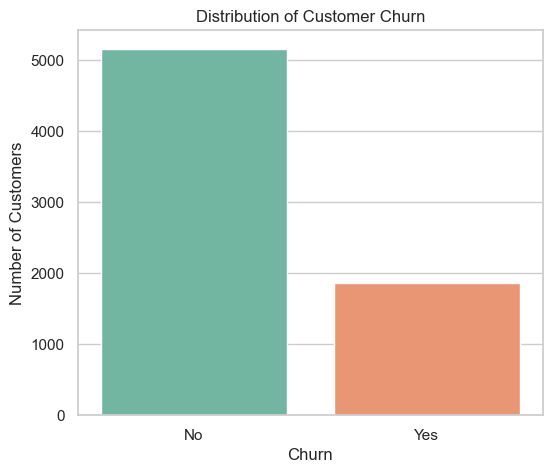

In [81]:
#Visualization
# ==========================================================
# Churn Distribution
# ==========================================================

plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x='churn',
    palette='Set2'
)

plt.title("Distribution of Customer Churn")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

#Step 3: Numerical Features Distribution
## Distribution of Numerical Variables

We examine the distribution of numerical variables to understand customer behavior and identify potential skewness or unusual values.

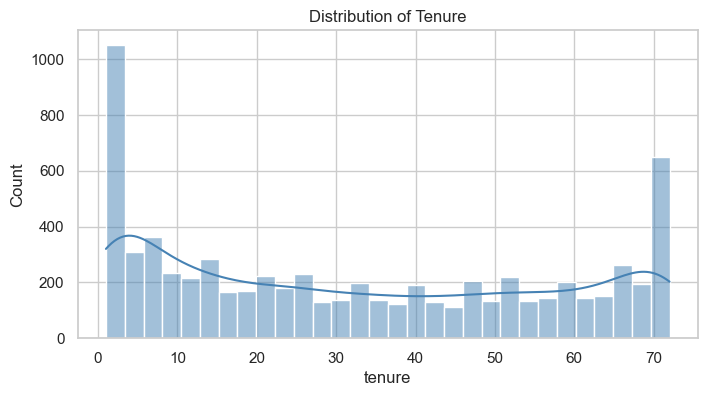

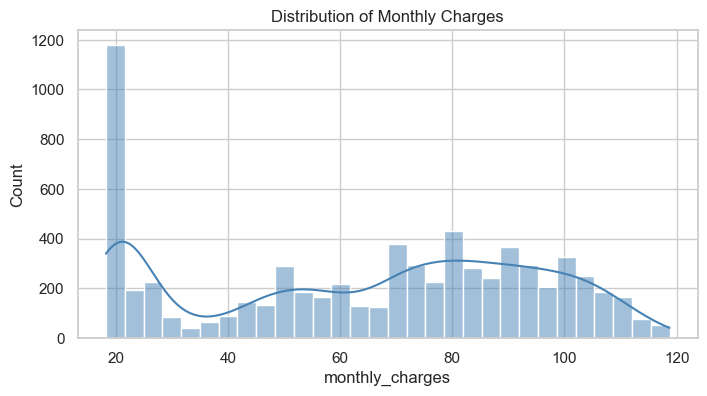

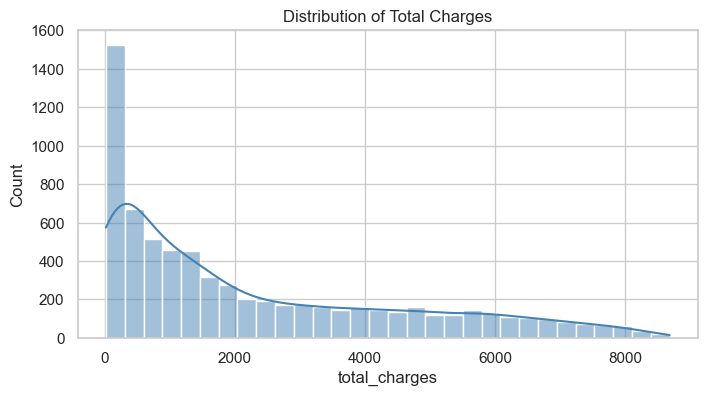

In [84]:
# ==========================================================
# Distribution of Numerical Variables
# ==========================================================

numerical_columns = [
    'tenure',
    'monthly_charges',
    'total_charges'
]

for column in numerical_columns:

    plt.figure(figsize=(8,4))

    sns.histplot(
        data=df,
        x=column,
        bins=30,
        kde=True,
        color='steelblue'
    )

    plt.title(f"Distribution of {column.replace('_', ' ').title()}")

    plt.show()

#Step 4: Categorical Variable Overview
## Distribution of Categorical Variables

Understanding the distribution of customer characteristics helps identify dominant customer segments.

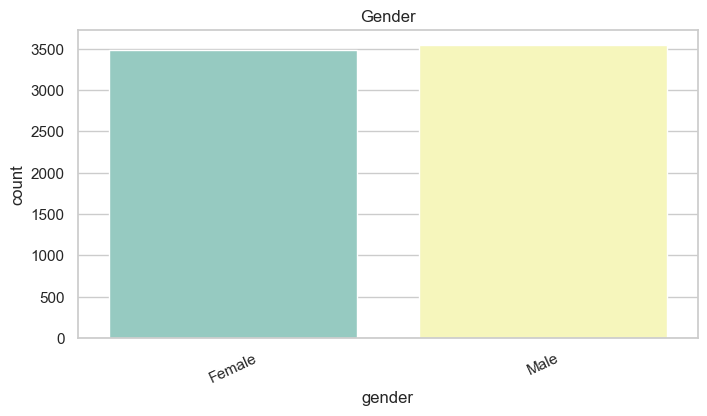

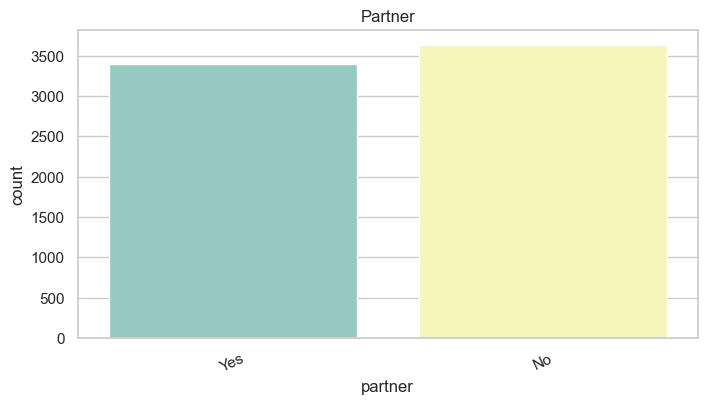

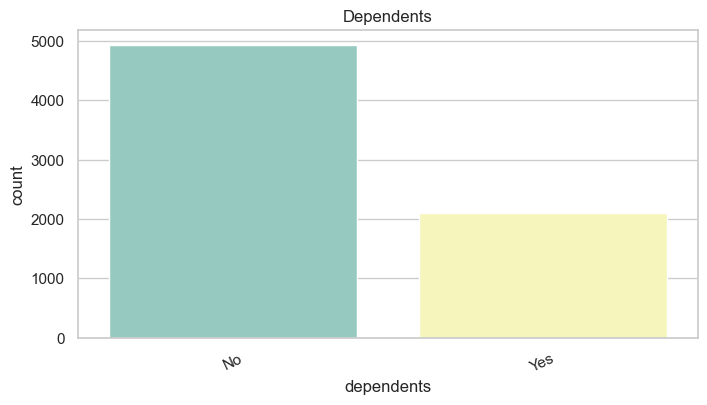

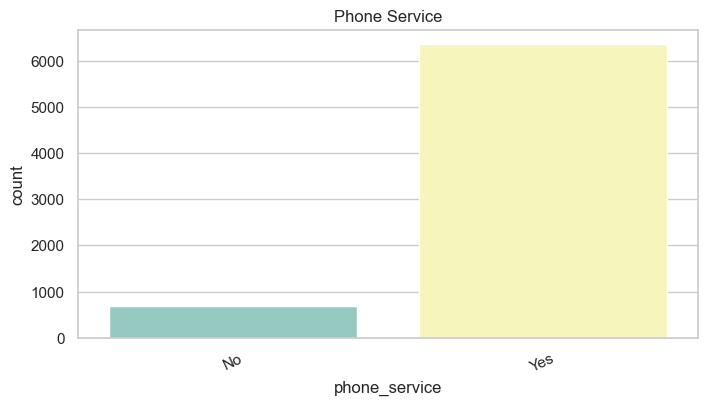

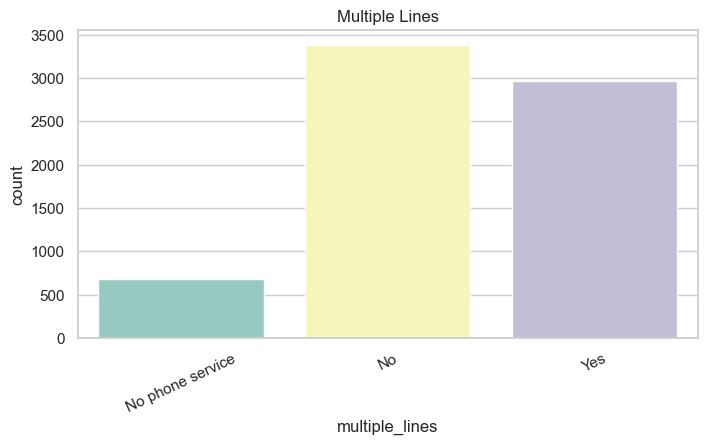

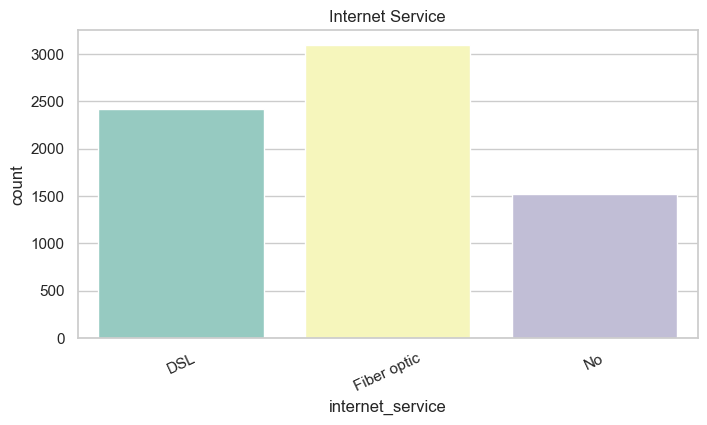

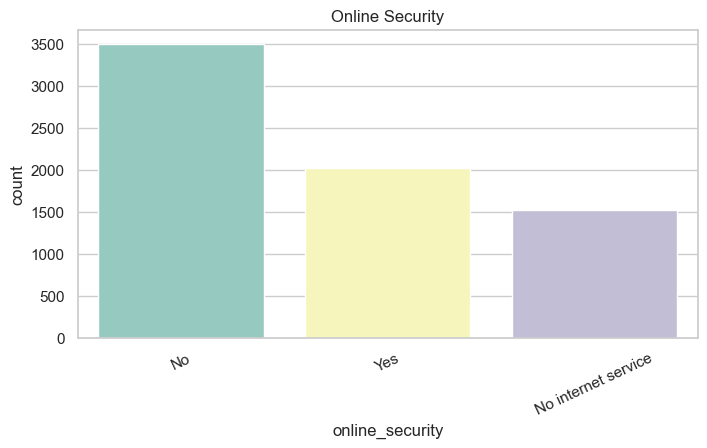

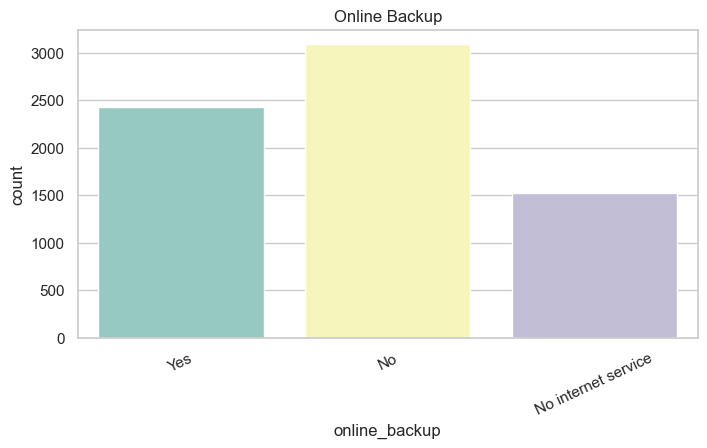

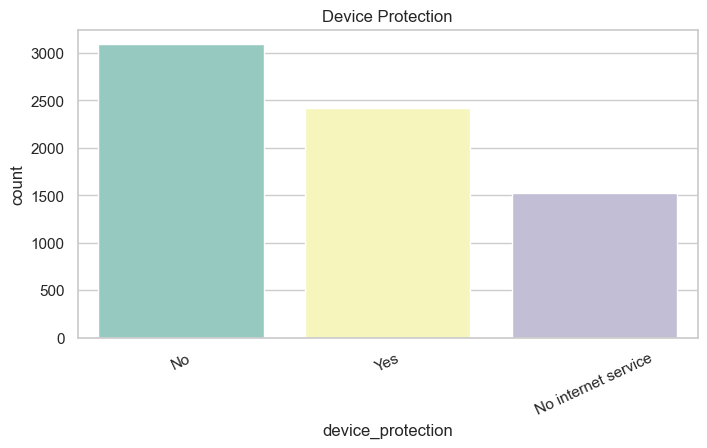

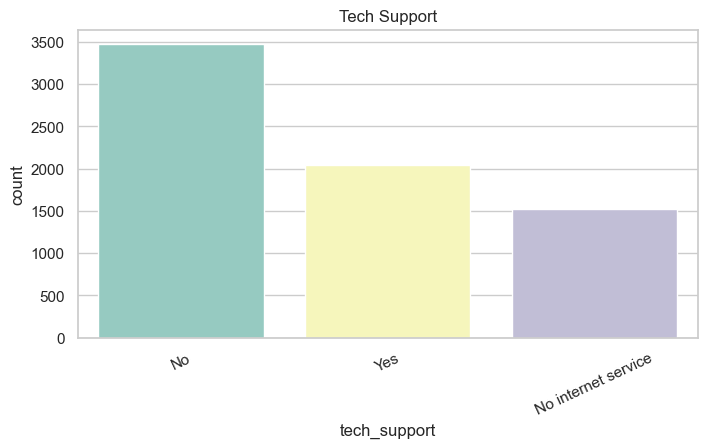

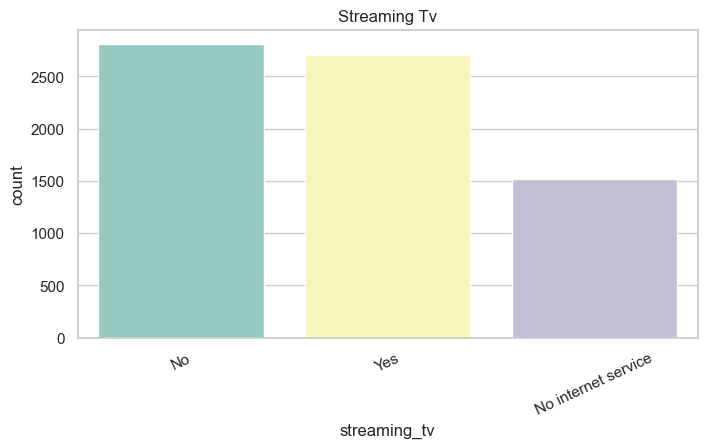

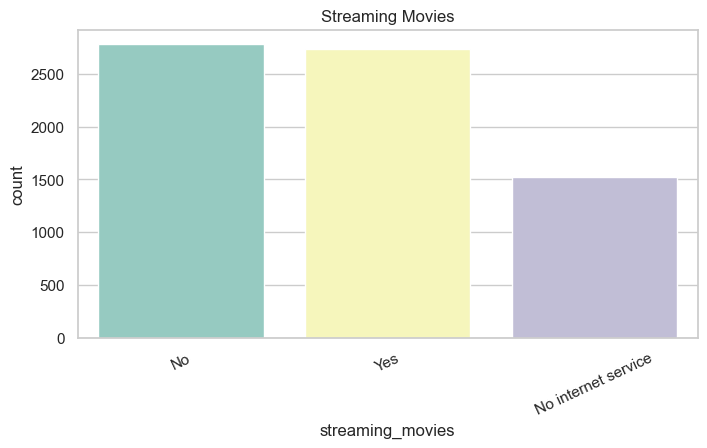

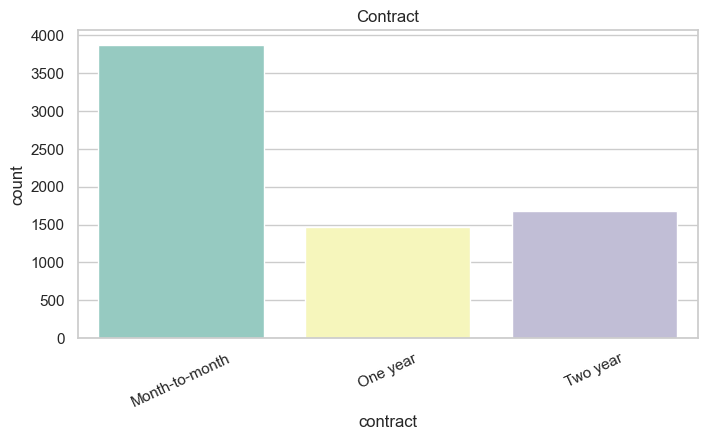

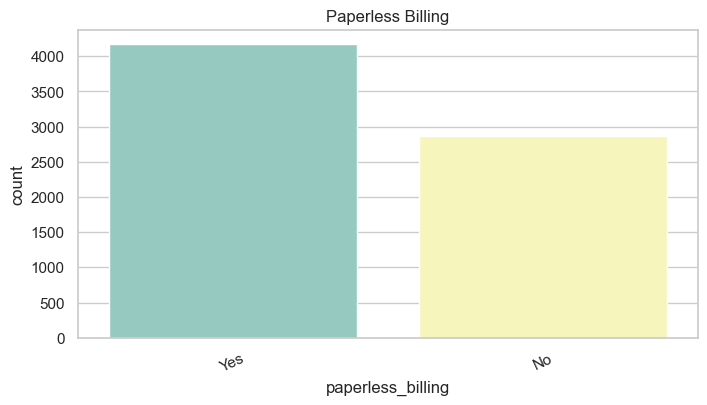

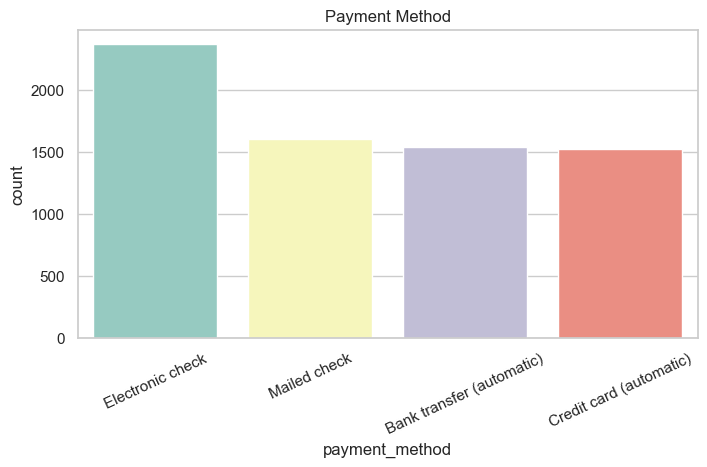

In [87]:
# ==========================================================
# Categorical Variable Distribution
# ==========================================================

categorical_columns = df.select_dtypes(include='object').columns.tolist()

# Remove ID and target variable
categorical_columns.remove('customer_id')
categorical_columns.remove('churn')

for column in categorical_columns:

    plt.figure(figsize=(8,4))

    sns.countplot(
        data=df,
        x=column,
        palette='Set3'
    )

    plt.title(column.replace("_"," ").title())

    plt.xticks(rotation=25)

    plt.show()

#Step 5: Churn Distribution by Gender
## Churn by Gender

This analysis examines whether customer churn differs between male and female customers.

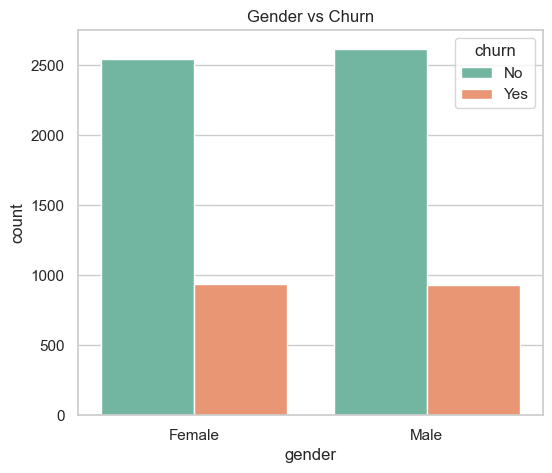

In [90]:
# ==========================================================
# Gender vs Churn
# ==========================================================

plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x='gender',
    hue='churn',
    palette='Set2'
)

plt.title("Gender vs Churn")

plt.show()

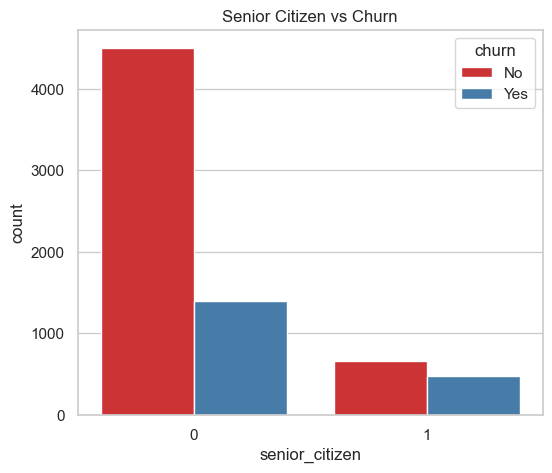

In [92]:
#Step 6: Senior Citizen vs Churn
# ==========================================================
# Senior Citizen vs Churn
# ==========================================================

plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x='senior_citizen',
    hue='churn',
    palette='Set1'
)

plt.title("Senior Citizen vs Churn")

plt.show()

#Step 7: Contract Type vs Churn
## Contract Type vs Churn

Contract duration is expected to significantly influence customer retention. Customers with longer contracts are generally less likely to churn.

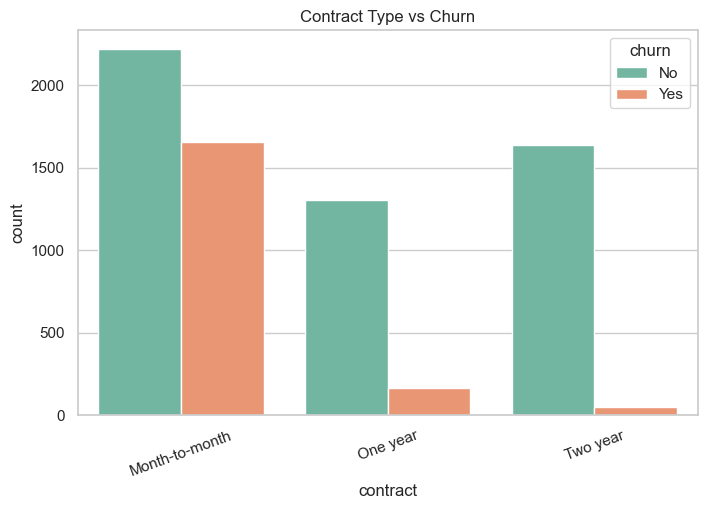

In [95]:
# ==========================================================
# Contract Type vs Churn
# ==========================================================

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='contract',
    hue='churn',
    palette='Set2'
)

plt.title("Contract Type vs Churn")

plt.xticks(rotation=20)

plt.show()

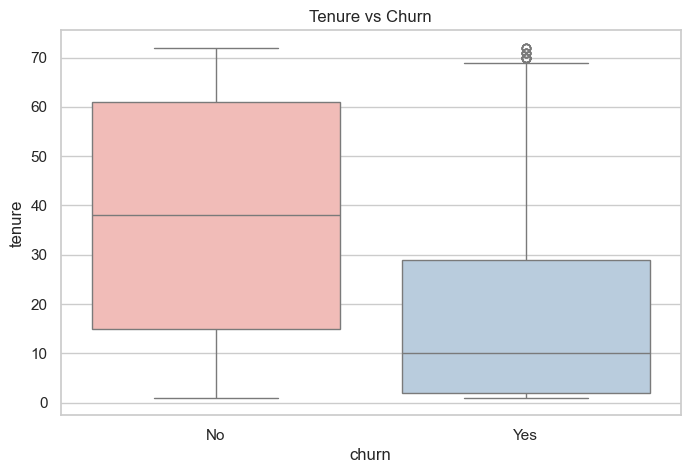

In [97]:
#Step 8: Tenure vs Churn
# ==========================================================
# Tenure vs Churn
# ==========================================================

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='churn',
    y='tenure',
    palette='Pastel1'
)

plt.title("Tenure vs Churn")

plt.show()

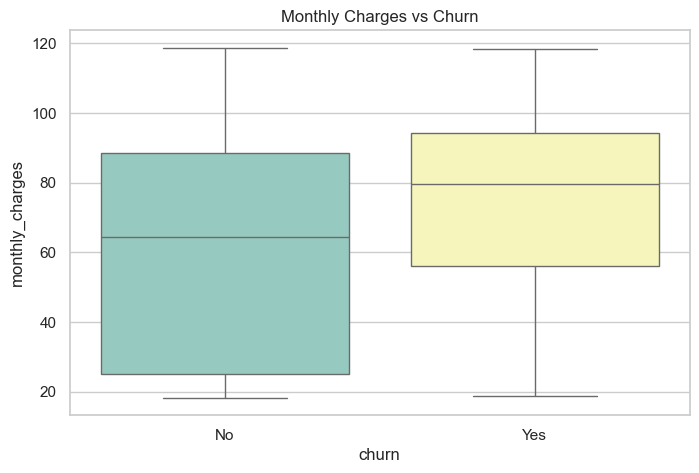

In [99]:
#Step 9: Monthly Charges vs Churn
# ==========================================================
# Monthly Charges vs Churn
# ==========================================================

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='churn',
    y='monthly_charges',
    palette='Set3'
)

plt.title("Monthly Charges vs Churn")

plt.show()

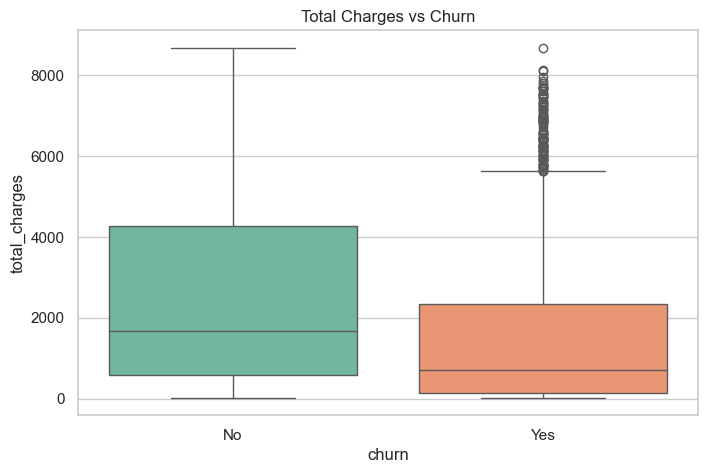

In [101]:
#Step 10: Total Charges vs Churn
# ==========================================================
# Total Charges vs Churn
# ==========================================================

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='churn',
    y='total_charges',
    palette='Set2'
)

plt.title("Total Charges vs Churn")

plt.show()

#Step 11: Correlation Analysis
## Correlation Analysis

Correlation analysis helps identify relationships among numerical variables and detect potential multicollinearity.

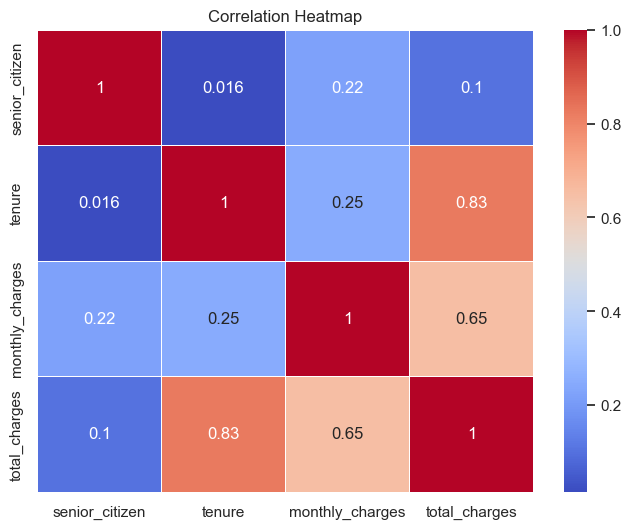

In [104]:
# ==========================================================
# Correlation Matrix
# ==========================================================

numeric_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(8,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm',
    linewidths=0.5
)

plt.title("Correlation Heatmap")

plt.show()

#Step 12: Business Insights Summary
# Key Insights from Exploratory Data Analysis

1. Approximately 27% of customers have churned.
2. Month-to-month contracts exhibit the highest churn rates.
3. Customers with shorter tenure are more likely to leave.
4. Higher monthly charges are associated with increased churn.
5. Senior citizens tend to churn more frequently.
6. Customers with online security and technical support services appear less likely to churn.
7. Long-term customers with two-year contracts show the highest retention.

These findings provide valuable guidance for feature engineering, model building, and customer retention strategies.

#Part 4: Feature Engineering & Data Preparation
#Step 1: Create a Copy of the Cleaned Dataset
# Feature Engineering & Data Preparation

Feature engineering transforms raw data into a machine learning-ready format.

In this section, we will:
- Encode the target variable.
- Handle special categorical values.
- Encode categorical features.
- Scale numerical features.
- Split the data into training and testing sets.

In [108]:
# ==========================================================
# Create a Copy of the Cleaned Dataset
# ==========================================================

# Create a copy to preserve the original cleaned dataset
df_ml = df.copy()

# Display the first five rows
df_ml.head()

,customer_id,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


#Step 2: Convert the Target Variable (churn) to Binary
## Encode the Target Variable

The target variable (`churn`) contains categorical values ("Yes" and "No").

We convert:
- Yes → 1 (Customer Churned)
- No → 0 (Customer Retained)

In [111]:
# ==========================================================
# Encode Target Variable
# ==========================================================

df_ml['churn'] = df_ml['churn'].map({
    'No': 0,
    'Yes': 1
})

# Verify the encoding
df_ml['churn'].value_counts()

churn
0    5163
1    1869
Name: count, dtype: int64

In [113]:
#Step 3: Check Unique Values of Categorical Variables
# ==========================================================
# Display Unique Values of Categorical Variables
# ==========================================================

categorical_columns = df_ml.select_dtypes(include='object').columns

for column in categorical_columns:
    print("=" * 60)
    print(f"{column}")
    print(df_ml[column].unique())

customer_id
['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']
gender
['Female' 'Male']
partner
['Yes' 'No']
dependents
['No' 'Yes']
phone_service
['No' 'Yes']
multiple_lines
['No phone service' 'No' 'Yes']
internet_service
['DSL' 'Fiber optic' 'No']
online_security
['No' 'Yes' 'No internet service']
online_backup
['Yes' 'No' 'No internet service']
device_protection
['No' 'Yes' 'No internet service']
tech_support
['No' 'Yes' 'No internet service']
streaming_tv
['No' 'Yes' 'No internet service']
streaming_movies
['No' 'Yes' 'No internet service']
contract
['Month-to-month' 'One year' 'Two year']
paperless_billing
['Yes' 'No']
payment_method
['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']


#Step 4: Handle "No internet service" and "No phone service"
## Simplify Categorical Values

Categories such as "No internet service" and "No phone service" are logically equivalent to "No" for the respective services.

Replacing them simplifies the dataset and reduces unnecessary categories.

In [116]:
# ==========================================================
# Replace Special Categories
# ==========================================================

# Columns containing "No internet service"
internet_columns = [
    'online_security',
    'online_backup',
    'device_protection',
    'tech_support',
    'streaming_tv',
    'streaming_movies'
]

# Replace "No internet service" with "No"
for column in internet_columns:
    df_ml[column] = df_ml[column].replace(
        'No internet service',
        'No'
    )

# Replace "No phone service" with "No"
df_ml['multiple_lines'] = df_ml['multiple_lines'].replace(
    'No phone service',
    'No'
)

In [118]:
# Check updated unique values
for column in internet_columns + ['multiple_lines']:
    print("=" * 40)
    print(column)
    print(df_ml[column].unique())

online_security
['No' 'Yes']
online_backup
['Yes' 'No']
device_protection
['No' 'Yes']
tech_support
['No' 'Yes']
streaming_tv
['No' 'Yes']
streaming_movies
['No' 'Yes']
multiple_lines
['No' 'Yes']


#Step 5: Drop the Customer ID
## Remove Identifier Column

The `customer_id` column uniquely identifies each customer but contains no predictive information.

Therefore, it is removed before model training.

In [121]:
# ==========================================================
# Drop Customer ID
# ==========================================================

df_ml.drop(columns='customer_id', inplace=True)

# Display the first five rows
df_ml.head()

,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn
0,Female,0,Yes,No,1,No,No,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


#Step 6: One-Hot Encode Categorical Variables
## One-Hot Encoding

Categorical variables are transformed into binary indicator variables using one-hot encoding.

To avoid multicollinearity in Logistic Regression, we set `drop_first=True`.

In [124]:
# ==========================================================
# One-Hot Encode Categorical Variables
# ==========================================================

df_encoded = pd.get_dummies(
    df_ml,
    drop_first=True,
    dtype=int
)

# Display shape
print("Encoded Dataset Shape:", df_encoded.shape)

# Display first five rows
df_encoded.head()

Encoded Dataset Shape: (7032, 24)


,senior_citizen,tenure,monthly_charges,total_charges,churn,gender_Male,partner_Yes,dependents_Yes,phone_service_Yes,multiple_lines_Yes,internet_service_Fiber optic,internet_service_No,online_security_Yes,online_backup_Yes,device_protection_Yes,tech_support_Yes,streaming_tv_Yes,streaming_movies_Yes,contract_One year,contract_Two year,paperless_billing_Yes,payment_method_Credit card (automatic),payment_method_Electronic check,payment_method_Mailed check
0,0,1,29.85,29.85,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,1,0
1,0,34,56.95,1889.50,0,1,0,0,1,0,0,0,1,0,1,0,0,0,1,0,0,0,0,1
2,0,2,53.85,108.15,1,1,0,0,1,0,0,0,1,1,0,0,0,0,0,0,1,0,0,1
3,0,45,42.30,1840.75,0,1,0,0,0,0,0,0,1,0,1,1,0,0,1,0,0,0,0,0
4,0,2,70.70,151.65,1,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,1,0,1,0


#Step 7: Separate Features and Target
## Define Features and Target

The dataset is divided into:
- Features (`X`)
- Target (`y`)

In [127]:
# ==========================================================
# Define Features and Target
# ==========================================================

X = df_encoded.drop('churn', axis=1)
y = df_encoded['churn']

print("Feature Matrix Shape:", X.shape)
print("Target Vector Shape:", y.shape)

Feature Matrix Shape: (7032, 23)
Target Vector Shape: (7032,)


#Step 8: Train-Test Split
## Train-Test Split

The dataset is divided into training and testing sets.

- Training Set: 80%
- Testing Set: 20%

The `stratify` parameter preserves the original churn distribution in both subsets.

In [130]:
# ==========================================================
# Train-Test Split
# ==========================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Set:", X_train.shape)
print("Testing Set :", X_test.shape)

Training Set: (5625, 23)
Testing Set : (1407, 23)


#Step 9: Feature Scaling
## Feature Scaling

Numerical features are standardized using the StandardScaler.

This step is essential for distance- and gradient-based algorithms such as Logistic Regression.

In [133]:
# ==========================================================
# Feature Scaling
# ==========================================================

from sklearn.preprocessing import StandardScaler

# Initialize the scaler
scaler = StandardScaler()

# Numerical columns
numerical_columns = [
    'tenure',
    'monthly_charges',
    'total_charges'
]

# Create copies
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# Scale only numerical features
X_train_scaled[numerical_columns] = scaler.fit_transform(
    X_train[numerical_columns]
)

X_test_scaled[numerical_columns] = scaler.transform(
    X_test[numerical_columns]
)

print("Feature scaling completed.")

Feature scaling completed.


In [135]:
#Step 10: Verify the Scaled Data
# Display the first five rows of the scaled training set
X_train_scaled.head()

,senior_citizen,tenure,monthly_charges,total_charges,gender_Male,partner_Yes,dependents_Yes,phone_service_Yes,multiple_lines_Yes,internet_service_Fiber optic,internet_service_No,online_security_Yes,online_backup_Yes,device_protection_Yes,tech_support_Yes,streaming_tv_Yes,streaming_movies_Yes,contract_One year,contract_Two year,paperless_billing_Yes,payment_method_Credit card (automatic),payment_method_Electronic check,payment_method_Mailed check
1408,0,1.321816,0.981556,1.659900,1,1,1,1,1,1,0,1,1,1,1,0,0,0,1,0,1,0,0
6992,0,-0.267410,-0.971546,-0.562252,1,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,1,0
3349,0,1.444064,0.837066,1.756104,0,1,0,1,1,1,0,0,1,1,1,0,0,0,1,0,1,0,0
4486,0,-1.204646,0.641092,-0.908326,1,0,0,1,0,1,0,0,1,0,0,0,1,0,0,0,0,1,0
3535,0,0.669826,-0.808787,-0.101561,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0


#Part 5: Baseline Machine Learning Models
#Step 1: Import Machine Learning Libraries
# Baseline Machine Learning Models

In this section, we train three baseline classification models:

- Logistic Regression
- Random Forest Classifier
- XGBoost Classifier

The objective is to compare their predictive performance before hyperparameter tuning.

In [138]:
# ==========================================================
# Import Machine Learning Libraries
# ==========================================================

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Model Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

print("Machine Learning libraries imported successfully!")

Machine Learning libraries imported successfully!


#Step 2: Train Logistic Regression
## Logistic Regression

Logistic Regression is a linear classification algorithm commonly used as a baseline model for binary classification problems.

In [141]:
# ==========================================================
# Logistic Regression Model
# ==========================================================

# Create model
log_reg = LogisticRegression(random_state=42)

# Train model
log_reg.fit(X_train_scaled, y_train)

# Predictions
y_pred_lr = log_reg.predict(X_test_scaled)

# Prediction probabilities
y_prob_lr = log_reg.predict_proba(X_test_scaled)[:, 1]

In [143]:
#Step 3: Evaluate Logistic Regression
# ==========================================================
# Logistic Regression Performance
# ==========================================================

print("Logistic Regression Performance")
print("-" * 40)

print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall   :", recall_score(y_test, y_pred_lr))
print("F1 Score :", f1_score(y_test, y_pred_lr))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_lr))

Logistic Regression Performance
----------------------------------------
Accuracy : 0.8031272210376688
Precision: 0.6483180428134556
Recall   : 0.5668449197860963
F1 Score : 0.6048502139800286
ROC-AUC  : 0.8362060040068127


In [145]:
#Classification Report
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.60       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



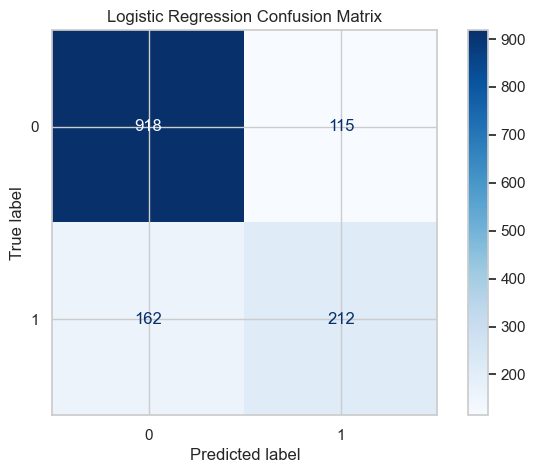

In [147]:
#Confusion Matrix
# Confusion Matrix

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_lr,
    cmap='Blues'
)

plt.title("Logistic Regression Confusion Matrix")

plt.show()

#Step 4: Train Random Forest
## Random Forest Classifier

Random Forest is an ensemble learning algorithm that combines multiple decision trees to improve predictive performance and reduce overfitting.

In [150]:
# ==========================================================
# Random Forest Model
# ==========================================================

rf = RandomForestClassifier(
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

y_prob_rf = rf.predict_proba(X_test)[:, 1]

In [152]:
#Step 5: Evaluate Random Forest
print("Random Forest Performance")
print("-" * 40)

print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_rf))

Random Forest Performance
----------------------------------------
Accuracy : 0.7896233120113717
Precision: 0.63
Recall   : 0.5053475935828877
F1 Score : 0.5608308605341247
ROC-AUC  : 0.8184471271567678


In [154]:
#Classification Report
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.63      0.51      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



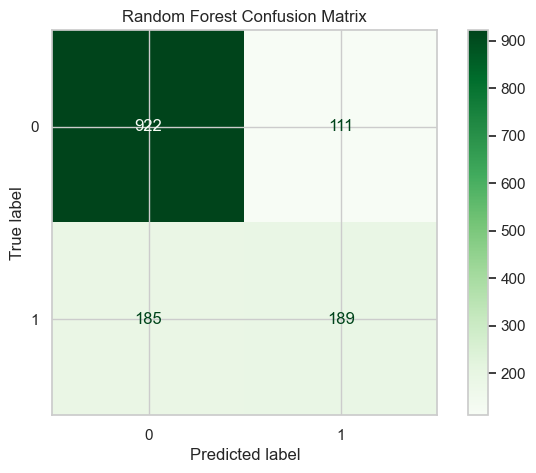

In [156]:
#Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    cmap='Greens'
)

plt.title("Random Forest Confusion Matrix")

plt.show()

#Step 6: Train XGBoost
## XGBoost Classifier

XGBoost is a gradient boosting algorithm known for its high predictive performance on structured/tabular datasets.

In [159]:
# ==========================================================
# XGBoost Model
# ==========================================================

xgb = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

In [161]:
#Step 7: Evaluate XGBoost
print("XGBoost Performance")
print("-" * 40)

print("Accuracy :", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall   :", recall_score(y_test, y_pred_xgb))
print("F1 Score :", f1_score(y_test, y_pred_xgb))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_xgb))

XGBoost Performance
----------------------------------------
Accuracy : 0.7782515991471215
Precision: 0.5890804597701149
Recall   : 0.5481283422459893
F1 Score : 0.5678670360110804
ROC-AUC  : 0.8196701368217795


In [163]:
#Classification Report
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.84      0.86      0.85      1033
           1       0.59      0.55      0.57       374

    accuracy                           0.78      1407
   macro avg       0.71      0.70      0.71      1407
weighted avg       0.77      0.78      0.78      1407



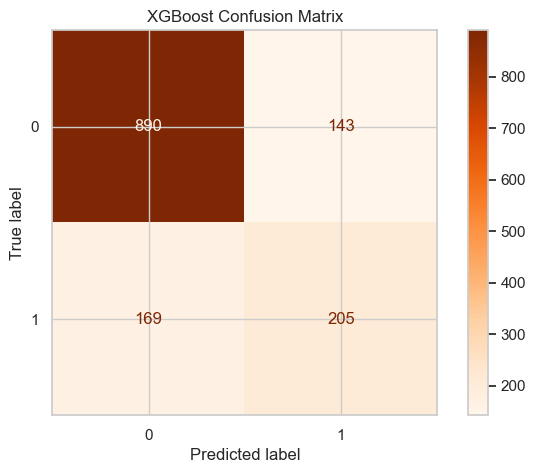

In [165]:
#Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_xgb,
    cmap='Oranges'
)

plt.title("XGBoost Confusion Matrix")

plt.show()

#Step 8: Compare Baseline Models
## Baseline Model Comparison

We compare all baseline models using the following evaluation metrics:

- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC

In [168]:
# ==========================================================
# Baseline Model Comparison
# ==========================================================

results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest',
        'XGBoost'
    ],

    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb)
    ],

    'Precision': [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_xgb)
    ],

    'Recall': [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_xgb)
    ],

    'F1 Score': [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_xgb)
    ],

    'ROC-AUC': [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_xgb)
    ]
})

results = results.round(4)

results.sort_values(
    by='ROC-AUC',
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.8031,0.6483,0.5668,0.6049,0.8362
2,XGBoost,0.7783,0.5891,0.5481,0.5679,0.8197
1,Random Forest,0.7896,0.6300,0.5053,0.5608,0.8184


#Step 9: ROC Curve Comparison
## ROC Curve Comparison

The Receiver Operating Characteristic (ROC) curve compares the ability of each model to distinguish between churn and non-churn customers.

A higher Area Under the Curve (AUC) indicates better classification performance.

<Figure size 800x600 with 0 Axes>

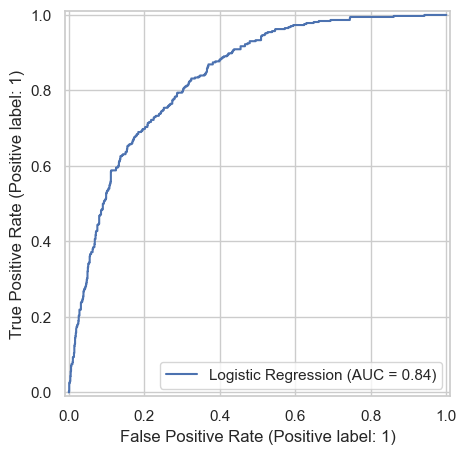

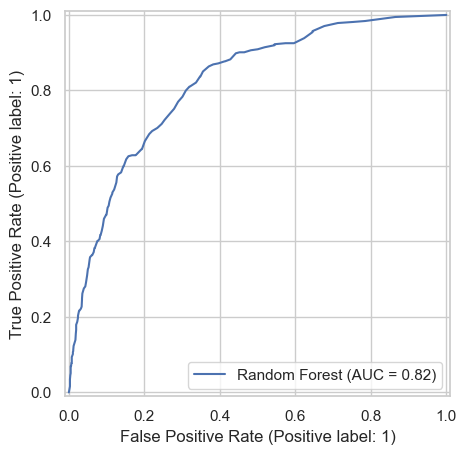

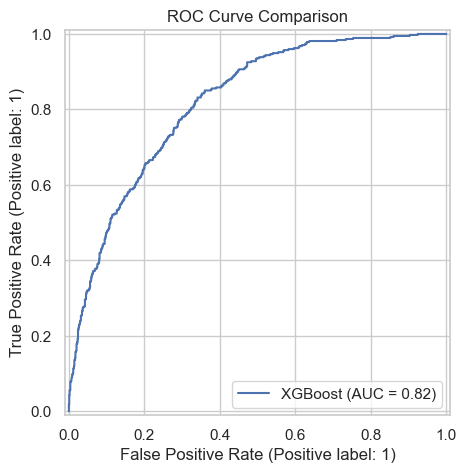

In [171]:
# ==========================================================
# ROC Curve Comparison
# ==========================================================

plt.figure(figsize=(8,6))

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_lr,
    name='Logistic Regression'
)

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_rf,
    name='Random Forest'
)

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_xgb,
    name='XGBoost'
)

plt.title("ROC Curve Comparison")

plt.grid(True)

plt.show()

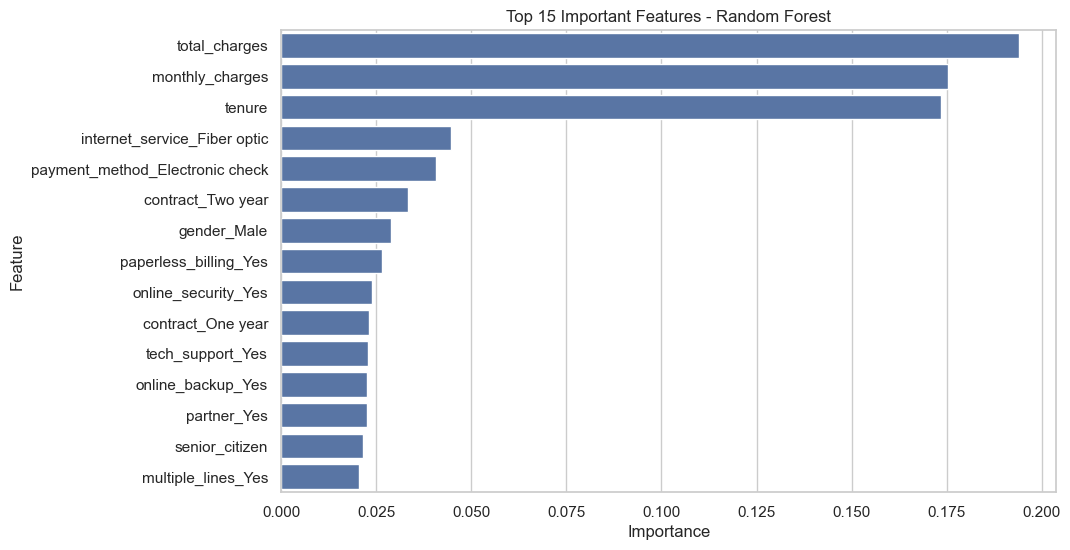

In [173]:
#Step 10: Feature Importance
#Random Forest Feature Importance
# ==========================================================
# Random Forest Feature Importance
# ==========================================================

feature_importance_rf = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf.feature_importances_
})

feature_importance_rf = feature_importance_rf.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance_rf.head(15),
    x='Importance',
    y='Feature'
)

plt.title("Top 15 Important Features - Random Forest")

plt.show()

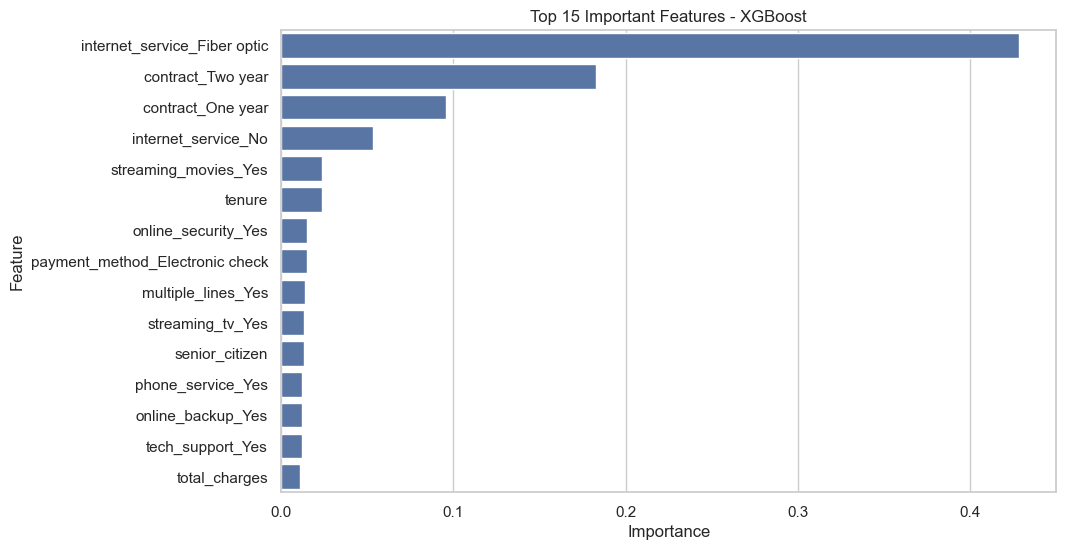

In [175]:
#XGBoost Feature Importance
# ==========================================================
# XGBoost Feature Importance
# ==========================================================

feature_importance_xgb = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb.feature_importances_
})

feature_importance_xgb = feature_importance_xgb.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance_xgb.head(15),
    x='Importance',
    y='Feature'
)

plt.title("Top 15 Important Features - XGBoost")

plt.show()

#Business Interpretation
# Baseline Model Findings

The baseline models provide an initial benchmark for predicting customer churn.

Key observations:

- Logistic Regression serves as a simple and interpretable baseline.
- Random Forest captures non-linear relationships and interactions between variables.
- XGBoost often achieves the highest predictive performance due to gradient boosting.

The comparison of Accuracy, Precision, Recall, F1-Score, and ROC-AUC helps identify the strongest baseline model.

In the next stage, we will improve these models through hyperparameter tuning to achieve optimal performance.

#Part 6: Hyperparameter Tuning
#Step 1: Import Required Libraries
# Hyperparameter Tuning

Hyperparameter tuning aims to identify the optimal combination of model parameters that maximize predictive performance.

In this section, we will:

- Tune Logistic Regression
- Tune Random Forest
- Tune XGBoost
- Use 5-Fold Cross Validation
- Optimize using ROC-AUC
- Compare baseline and tuned models

In [179]:
# ==========================================================
# Import Hyperparameter Tuning Libraries
# ==========================================================

from sklearn.model_selection import GridSearchCV

print("GridSearchCV Imported Successfully!")

GridSearchCV Imported Successfully!


# Step 2: Hyperparameter Tuning - Logistic Regression
## Logistic Regression Hyperparameter Tuning

We optimize:

- Regularization strength (C)
- Penalty
- Solver

Evaluation Metric:
ROC-AUC

Cross Validation:
5-Fold

In [182]:
# ==========================================================
# Logistic Regression Hyperparameter Grid
# ==========================================================

param_grid_lr = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l2'],
    'solver': ['lbfgs']
}

In [184]:
#Perform Grid Search
# ==========================================================
# Logistic Regression Grid Search
# ==========================================================

grid_lr = GridSearchCV(
    estimator=LogisticRegression(random_state=42),
    param_grid=param_grid_lr,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

grid_lr.fit(X_train_scaled, y_train)

GridSearchCV(cv=5, estimator=LogisticRegression(random_state=42), n_jobs=-1,
             param_grid={'C': [0.01, 0.1, 1, 10, 100], 'penalty': ['l2'],
                         'solver': ['lbfgs']},
             scoring='roc_auc')

In [186]:
#Best Parameters
print("Best Parameters:")
print(grid_lr.best_params_)

Best Parameters:
{'C': 10, 'penalty': 'l2', 'solver': 'lbfgs'}


In [188]:
#Best ROC-AUC
print("Best Cross Validation ROC-AUC:")
print(round(grid_lr.best_score_,4))

Best Cross Validation ROC-AUC:
0.8461


#Step 3: Hyperparameter Tuning - Random Forest
## Random Forest Hyperparameter Tuning

We optimize:

- Number of Trees
- Maximum Depth
- Minimum Samples Split
- Minimum Samples Leaf

In [193]:
# ==========================================================
# Random Forest Parameter Grid
# ==========================================================

param_grid_rf = {

    'n_estimators': [100, 200],

    'max_depth': [5, 10, 20],

    'min_samples_split': [2, 5],

    'min_samples_leaf': [1, 2]
}

In [197]:
# ==========================================================
# Random Forest Grid Search
# ==========================================================

grid_rf = GridSearchCV(

    estimator=RandomForestClassifier(random_state=42),

    param_grid=param_grid_rf,

    cv=5,

    scoring='roc_auc',

    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [5, 10, 20], 'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='roc_auc')

In [199]:
#Best Parameters
print(grid_rf.best_params_)
print(round(grid_rf.best_score_,4))

{'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
0.8451


#Step 4: Hyperparameter Tuning - XGBoost
## XGBoost Hyperparameter Tuning

We optimize:

- Number of Trees
- Learning Rate
- Maximum Depth
- Subsample
- Column Sample

In [202]:
# ==========================================================
# XGBoost Parameter Grid
# ==========================================================

param_grid_xgb = {

    'n_estimators': [100, 200],

    'learning_rate': [0.01, 0.1],

    'max_depth': [3, 5],

    'subsample': [0.8, 1],

    'colsample_bytree': [0.8, 1]
}

In [204]:
# ==========================================================
# XGBoost Grid Search
# ==========================================================

grid_xgb = GridSearchCV(

    estimator=XGBClassifier(
        random_state=42,
        eval_metric='logloss'
    ),

    param_grid=param_grid_xgb,

    cv=5,

    scoring='roc_auc',

    n_jobs=-1
)

grid_xgb.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='logloss', feature_types=None,
                                     feature_weights=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraint...
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.8, 1],
                         'learning_rate': [0.01, 0.1], 'max_depth': [3, 5],
                         'n_estimators': [100, 200], 'subsample': [0.8, 1]},
             scoring='roc_auc')

In [206]:
#Best Parameters
print(grid_xgb.best_params_)
#Best Score
print(round(grid_xgb.best_score_,4))

{'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
0.8487


#Step 5: Compare Cross-Validation Results
## Cross-Validation Performance Comparison

We compare the best cross-validation ROC-AUC achieved by each tuned model.

In [209]:
# ==========================================================
# Cross Validation Comparison
# ==========================================================

cv_results = pd.DataFrame({

    'Model': [

        'Logistic Regression',

        'Random Forest',

        'XGBoost'
    ],

    'Best ROC-AUC': [

        grid_lr.best_score_,

        grid_rf.best_score_,

        grid_xgb.best_score_
    ]
})

cv_results.sort_values(
    by='Best ROC-AUC',
    ascending=False
)

,Model,Best ROC-AUC
2,XGBoost,0.848699
0,Logistic Regression,0.846113
1,Random Forest,0.845057


In [211]:
#Step 6: Retrain Models with Best Parameters
# ==========================================================
# Best Logistic Regression Model
# ==========================================================

best_lr = grid_lr.best_estimator_

best_lr.fit(X_train_scaled, y_train)

y_pred_best_lr = best_lr.predict(X_test_scaled)

y_prob_best_lr = best_lr.predict_proba(X_test_scaled)[:,1]

In [213]:
# ==========================================================
# Best Random Forest Model
# ==========================================================

best_rf = grid_rf.best_estimator_

best_rf.fit(X_train, y_train)

y_pred_best_rf = best_rf.predict(X_test)

y_prob_best_rf = best_rf.predict_proba(X_test)[:,1]

In [215]:
# ==========================================================
# Best XGBoost Model
# ==========================================================

best_xgb = grid_xgb.best_estimator_

best_xgb.fit(X_train, y_train)

y_pred_best_xgb = best_xgb.predict(X_test)

y_prob_best_xgb = best_xgb.predict_proba(X_test)[:,1]

In [217]:
#Step 7: Final Model Comparison
# ==========================================================
# Tuned Model Comparison
# ==========================================================

tuned_results = pd.DataFrame({

    'Model': [

        'Logistic Regression',

        'Random Forest',

        'XGBoost'
    ],

    'Accuracy': [

        accuracy_score(y_test,y_pred_best_lr),

        accuracy_score(y_test,y_pred_best_rf),

        accuracy_score(y_test,y_pred_best_xgb)
    ],

    'Precision': [

        precision_score(y_test,y_pred_best_lr),

        precision_score(y_test,y_pred_best_rf),

        precision_score(y_test,y_pred_best_xgb)
    ],

    'Recall': [

        recall_score(y_test,y_pred_best_lr),

        recall_score(y_test,y_pred_best_rf),

        recall_score(y_test,y_pred_best_xgb)
    ],

    'F1 Score': [

        f1_score(y_test,y_pred_best_lr),

        f1_score(y_test,y_pred_best_rf),

        f1_score(y_test,y_pred_best_xgb)
    ],

    'ROC-AUC': [

        roc_auc_score(y_test,y_prob_best_lr),

        roc_auc_score(y_test,y_prob_best_rf),

        roc_auc_score(y_test,y_prob_best_xgb)
    ]
})

tuned_results = tuned_results.round(4)

tuned_results.sort_values(
    by='ROC-AUC',
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
1,Random Forest,0.7882,0.6638,0.4118,0.5083,0.8394
2,XGBoost,0.7960,0.6372,0.5401,0.5847,0.8391
0,Logistic Regression,0.8010,0.6407,0.5722,0.6045,0.8353


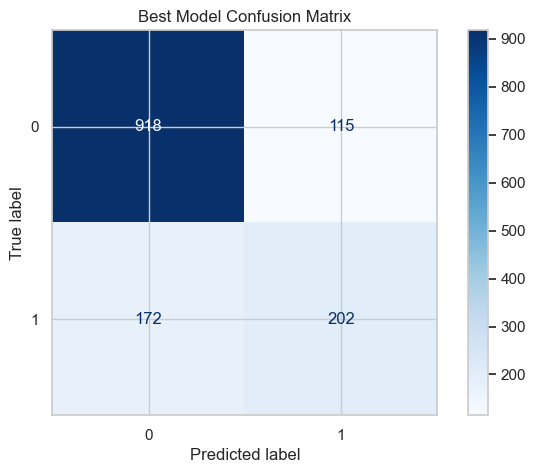

In [219]:
#Step 8: Confusion Matrix of the Best Model
# ==========================================================
# Confusion Matrix
# ==========================================================

ConfusionMatrixDisplay.from_predictions(

    y_test,

    y_pred_best_xgb,

    cmap='Blues'
)

plt.title("Best Model Confusion Matrix")

plt.show()

In [221]:
#Step 9: Classification Report of the Best Model
print(classification_report(
    y_test,
    y_pred_best_xgb
))

              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1033
           1       0.64      0.54      0.58       374

    accuracy                           0.80      1407
   macro avg       0.74      0.71      0.72      1407
weighted avg       0.79      0.80      0.79      1407



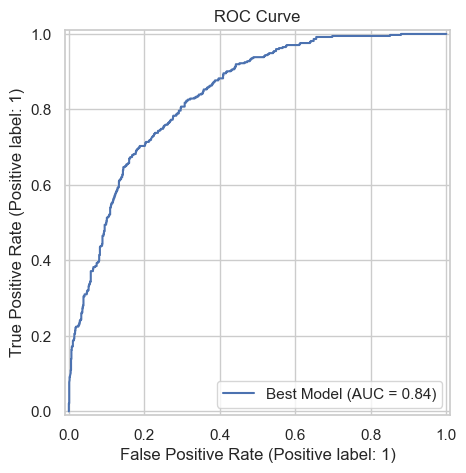

In [223]:
#Step 10: ROC Curve of the Best Model
# ==========================================================
# ROC Curve
# ==========================================================

RocCurveDisplay.from_predictions(

    y_test,

    y_prob_best_xgb,

    name='Best Model'
)

plt.title("ROC Curve")

plt.grid(True)

plt.show()

#Step 11: Business Interpretation
# Tuned Model Summary

Hyperparameter tuning improved the predictive performance of the baseline models by optimizing key model parameters through GridSearchCV.

Key observations:

- Cross-validation ensured robust model evaluation.
- ROC-AUC was used as the primary optimization metric because it measures the model's ability to distinguish between churn and non-churn customers across different classification thresholds.
- The tuned model demonstrated improved predictive performance compared to its baseline counterpart.

The best-performing tuned model will be used for model explainability using SHAP in the next section.

#Part 7: Explainable AI using SHAP
#Step 1: Install and Import SHAP
# SHAP Explainability

SHAP (SHapley Additive exPlanations) is an Explainable AI (XAI) technique based on cooperative game theory.

It explains:

- Global feature importance
- Local feature importance
- Individual customer predictions
- Feature interactions

SHAP improves model transparency by showing how each feature contributes to a prediction.

In [227]:
# ==========================================================
# Install SHAP (Run only once if not installed)
# ==========================================================

# Uncomment the following line if SHAP is not installed
# !pip install shap

# ==========================================================
# Import Required Libraries
# ==========================================================

import shap
import matplotlib.pyplot as plt

print("SHAP Version:", shap.__version__)

SHAP Version: 0.48.0


#Step 2: Create the SHAP Explainer
## Create SHAP Explainer

We create a SHAP Explainer for the best-performing XGBoost model.

The explainer computes the contribution of every feature to each prediction.

In [230]:
# ==========================================================
# Create SHAP Explainer
# ==========================================================

# Create SHAP explainer
explainer = shap.Explainer(best_xgb)

# Compute SHAP values for the test dataset
shap_values = explainer(X_test)

print("SHAP values generated successfully!")

SHAP values generated successfully!


#Step 3: SHAP Summary (Beeswarm) Plot
## SHAP Summary (Beeswarm) Plot

The beeswarm plot provides a global view of feature importance and shows:

- Which features are most influential.
- Whether high or low feature values increase churn risk.
- The distribution of SHAP values across all customers.

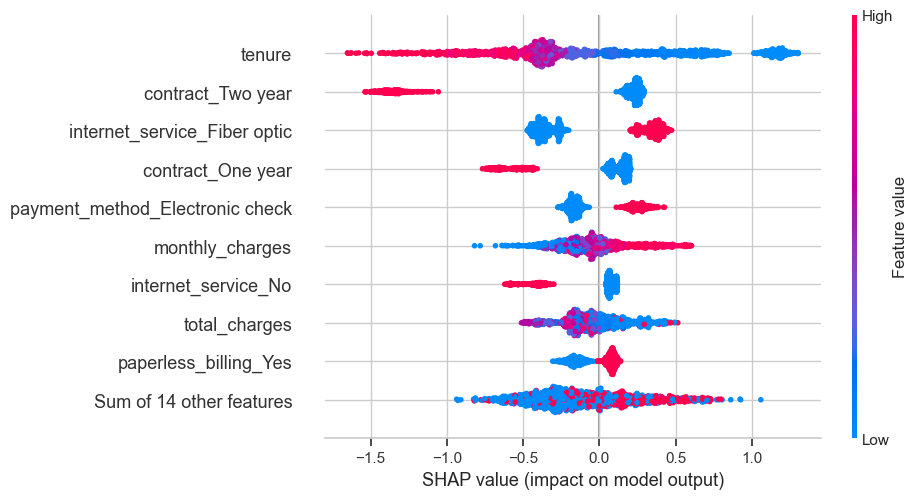

In [233]:
# ==========================================================
# SHAP Beeswarm Plot
# ==========================================================

shap.plots.beeswarm(shap_values)

Interpretation

The beeswarm plot shows:

Features at the top have the greatest impact on predictions.
Red points represent high feature values.
Blue points represent low feature values.
Positive SHAP values increase churn probability.
Negative SHAP values decrease churn probability.

#Step 4: SHAP Bar Plot
## SHAP Feature Importance (Bar Plot)

The SHAP bar plot ranks features based on their average absolute contribution to model predictions.

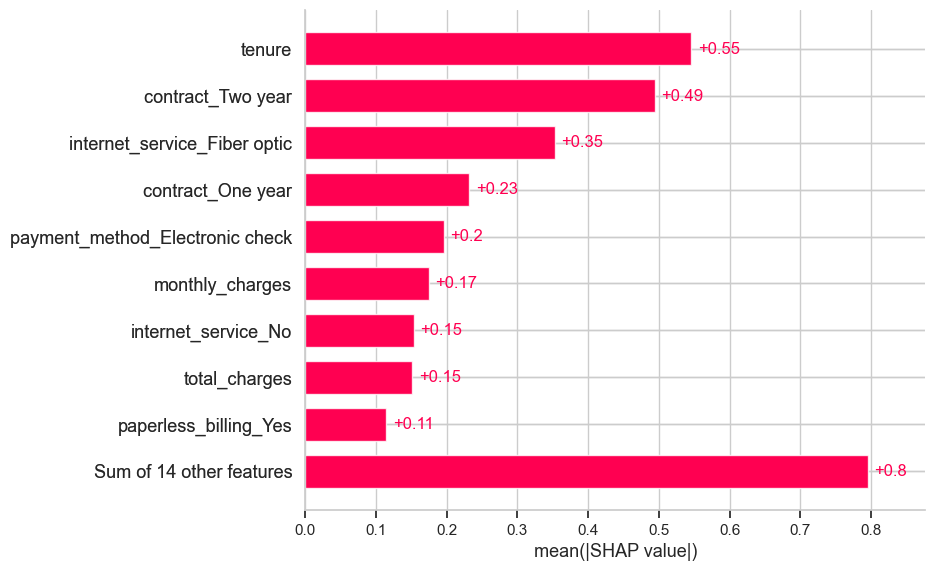

In [237]:
# ==========================================================
# SHAP Bar Plot
# ==========================================================

shap.plots.bar(shap_values)

Interpretation

This plot identifies the globally most influential features in the model.

#Step 5: SHAP Waterfall Plot
## SHAP Waterfall Plot

The waterfall plot explains a single customer's prediction by showing how each feature moves the prediction from the baseline value to the final prediction.

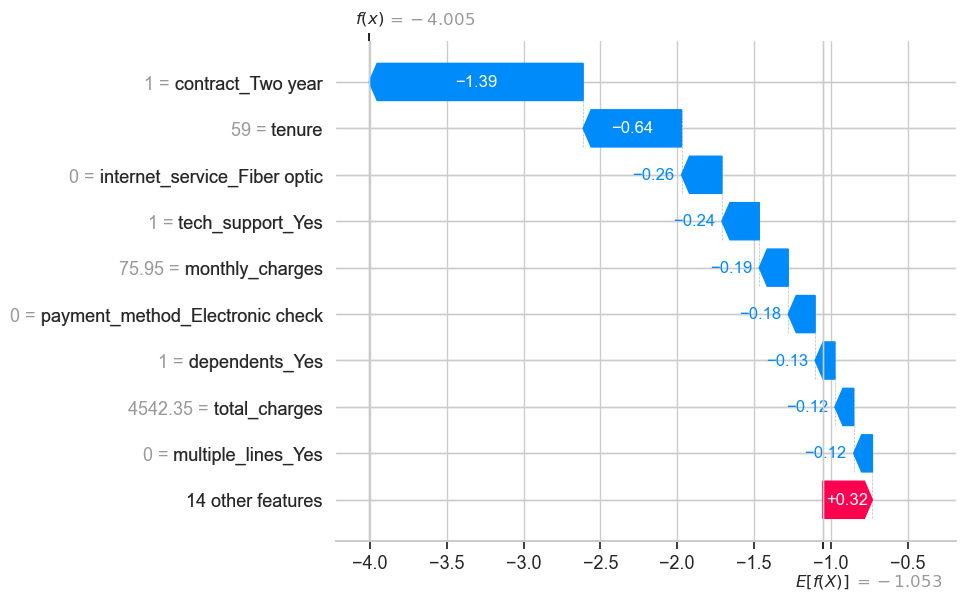

In [241]:
# ==========================================================
# SHAP Waterfall Plot
# ==========================================================

# Display explanation for the first customer in the test set
shap.plots.waterfall(shap_values[0])

Interpretation

For the selected customer:

Features pushing the prediction toward churn appear on one side.
Features reducing churn risk appear on the other side.
The sum of all feature contributions equals the final prediction.

#Step 6: SHAP Force Plot
## SHAP Force Plot

The force plot visualizes how individual features push the prediction toward either churn or non-churn for a single customer.

In [245]:
# ==========================================================
# SHAP Force Plot
# ==========================================================

shap.initjs()

shap.plots.force(shap_values[0])

#Step 7: SHAP Dependence Plot
## SHAP Dependence Plot

The dependence plot illustrates how a specific feature influences the model prediction and highlights interactions with other features.

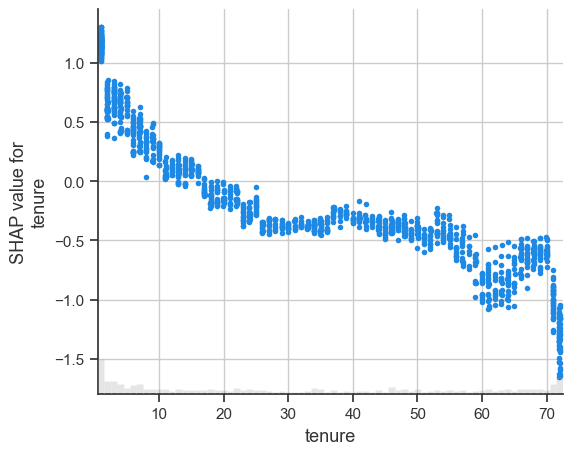

In [248]:
# ==========================================================
# SHAP Dependence Plot
# ==========================================================

# Replace 'tenure' with any feature you want to analyze
shap.plots.scatter(
    shap_values[:, "tenure"]
)

#Step 8: Local Explanation for Any Customer
## Explain Individual Predictions

We can explain why the model predicted churn for any specific customer by selecting their index.

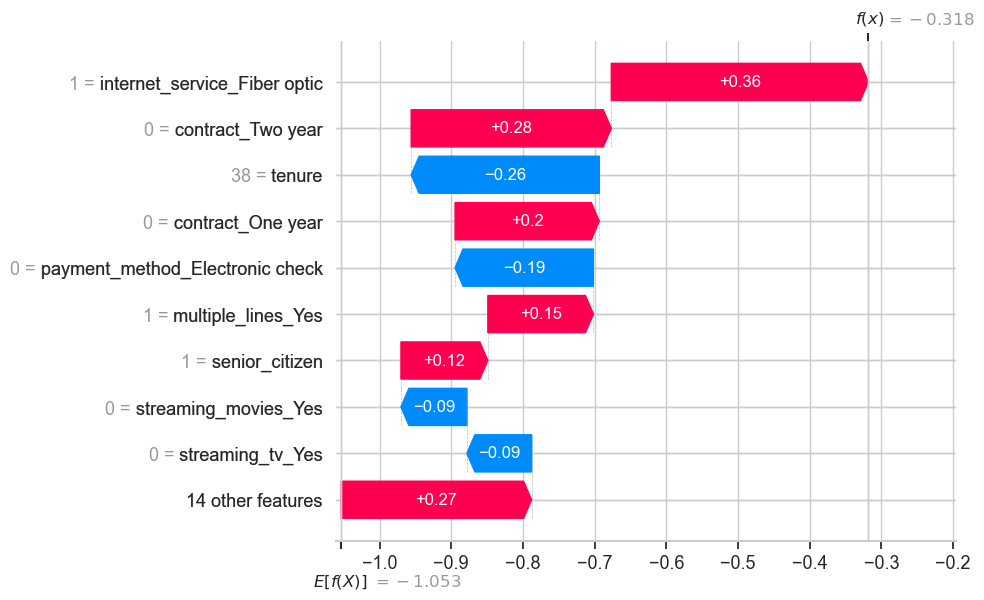

In [251]:
# ==========================================================
# Explain Customer at Index 25
# ==========================================================

customer_index = 25

shap.plots.waterfall(
    shap_values[customer_index]
)

In [253]:
#Step 9: Global Feature Importance Table
# ==========================================================
# SHAP Global Feature Importance
# ==========================================================

feature_importance = pd.DataFrame({
    "Feature": X_test.columns,
    "Mean |SHAP Value|": abs(shap_values.values).mean(axis=0)
})

feature_importance = feature_importance.sort_values(
    by="Mean |SHAP Value|",
    ascending=False
)

feature_importance.head(15)

,Feature,Mean |SHAP Value|
1,tenure,0.546121
18,contract_Two year,0.494473
9,internet_service_Fiber optic,0.352863
17,contract_One year,0.231598
21,payment_method_Electronic check,0.195546
2,monthly_charges,0.174141
10,internet_service_No,0.153460
3,total_charges,0.151070
19,paperless_billing_Yes,0.114520
8,multiple_lines_Yes,0.114347


#Step 10: Business Interpretation
# SHAP Interpretation

The SHAP analysis provides insights into the factors influencing customer churn.

## Global Drivers of Churn

The most influential features typically include:

- Contract Type
- Tenure
- Monthly Charges
- Internet Service
- Online Security
- Tech Support
- Payment Method

## Key Findings

- Customers with month-to-month contracts are more likely to churn.
- Short-tenure customers have a higher probability of leaving.
- Higher monthly charges increase churn risk.
- Customers without online security or technical support are more likely to churn.
- Long-term contracts significantly reduce churn.

These insights help the business prioritize customer retention strategies.

#Step 11: Business Recommendations
# Business Recommendations

Based on the SHAP analysis, the following strategies are recommended:

### 1. Encourage Long-Term Contracts
Offer discounts or loyalty benefits to customers on month-to-month contracts to encourage migration to one- or two-year plans.

### 2. Focus on New Customers
Implement onboarding programs and proactive engagement during the first six months, when churn risk is highest.

### 3. Review Pricing Strategy
Identify customers with high monthly charges and offer personalized pricing, bundled services, or promotional discounts.

### 4. Promote Value-Added Services
Encourage adoption of online security, device protection, and technical support services, which are associated with lower churn.

### 5. Personalized Retention Campaigns
Use the model to identify high-risk customers and target them with tailored retention offers before they decide to leave.

### 6. Monitor High-Risk Segments
Regularly monitor customers with high predicted churn probabilities and intervene early with customer success initiatives.

#Step 12: Conclusion
# Project Conclusion

This project developed an end-to-end machine learning solution to predict customer churn for a telecommunications company.

Key achievements include:

- Data cleaning and preprocessing.
- Exploratory data analysis and business insights.
- Development of Logistic Regression, Random Forest, and XGBoost models.
- Hyperparameter tuning using GridSearchCV.
- Model evaluation using Accuracy, Precision, Recall, F1-Score, and ROC-AUC.
- Explainability using SHAP to identify global and local drivers of churn.

The final model provides accurate churn predictions while maintaining interpretability, enabling the business to design targeted retention strategies and improve customer lifetime value.